<a href="https://colab.research.google.com/github/grullaandrea-png/Deep_Learning/blob/main/model_transformation_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Unzip the files

In [ ]:
!mkdir -p /content/dataset
!unzip "/content/drive/MyDrive/Deep_learning_project/archive (9).zip" -d "/content/dataset"

Output streaming troncato alle ultime 5000 righe.
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AE2014PIC62591207.jpg_545e1a0f-1d78-492a-8709-9f5ceb43569f.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AE2014PIC62591207.jpg_e4d7c54d-d437-43fe-b6b5-eab0ddbd559a.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AE2015PIC76548267.jpg_61ebf998-b459-4fc7-8d59-d17a49089c7f.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_ALO2015PIC74715276.jpg_dbd2bff2-da30-47c6-ae31-5cdc47175911.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_ALO2015PIC74715276.jpg_ff6e1280-44e5-44aa-8220-435738b08997.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_ANB2016-9178693_rkxA21PQyx.jpg_89b988b0-c4ae-4c8c-8c92-879b4e0d2a90.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AS2009PIC41853880.jpg_27349cea-c52c-483d-b2dd-e99ced31da85.jpg  
  inflating: /content/dataset/Data/Inocybe/Inocybe_original_AS20

In [ ]:
import os

data_dir = '/content/dataset/Data'
print("Classes found:", os.listdir(data_dir))

# where data are estracted
dataset_path = '/content/dataset/Data'

conteggi = {}

if os.path.exists(dataset_path):
    # all class folders
    classi = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

    for classe in classi:
        path_classe = os.path.join(dataset_path, classe)
        n_imagins = len(os.listdir(path_classe))
        conteggi[classe] = n_imagins
        print(f"Class: {classe:<20} | Imagins: {n_imagins}")

    print("-" * 40)
    print(f"Total imagins: {sum(conteggi.values())}")
else:
    print("Error: folder doesn't found")

Classes found: ['Cortinarius', 'Agaricus', 'Pluteus', 'Entoloma', 'Boletus', 'Suillus', 'Lactarius', 'Russula', 'Inocybe', 'Exidia', 'Amanita', 'Hygrocybe']
Class: Cortinarius          | Imagins: 1000
Class: Agaricus             | Imagins: 1000
Class: Pluteus              | Imagins: 1000
Class: Entoloma             | Imagins: 1000
Class: Boletus              | Imagins: 1000
Class: Suillus              | Imagins: 1000
Class: Lactarius            | Imagins: 1000
Class: Russula              | Imagins: 1000
Class: Inocybe              | Imagins: 1000
Class: Exidia               | Imagins: 1000
Class: Amanita              | Imagins: 1000
Class: Hygrocybe            | Imagins: 1000
----------------------------------------
Total imagins: 12000


Trasform the images in mathematical values in order to start our analysis

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import os

data_dir = '/content/dataset/Data'
batch_size = 32
img_height, img_width = 224, 224

data_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=data_transforms)

# Compute dimension for the split (70% - 10% - 20%)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size
print(f"Total images: {total_size}")
print(f"Training: {train_size} | Validation: {val_size} | Test: {test_size}")



from torchvision import transforms

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Subset
import copy

# dataset without trasformations
full_dataset = ImageFolder(root='/content/dataset/Data')

# casual division
generator = torch.Generator().manual_seed(42)
train_indices, val_indices, test_indices = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

# Define a small class for compute the specific transformation
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# Apply the trasformations
train_dataset = ApplyTransform(train_indices, transform=data_transforms['train'])
val_dataset = ApplyTransform(val_indices, transform=data_transforms['val'])
test_dataset = ApplyTransform(test_indices, transform=data_transforms['val']) # Test usa le stesse di Val

# Create the DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### print("DataLoader created successfully!")

Total images: 12000
Training: 8400 | Validation: 1200 | Test: 2400


Check if the images belongs to the correct class

Classes: ['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Exidia', 'Hygrocybe', 'Inocybe', 'Lactarius', 'Pluteus', 'Russula', 'Suillus']


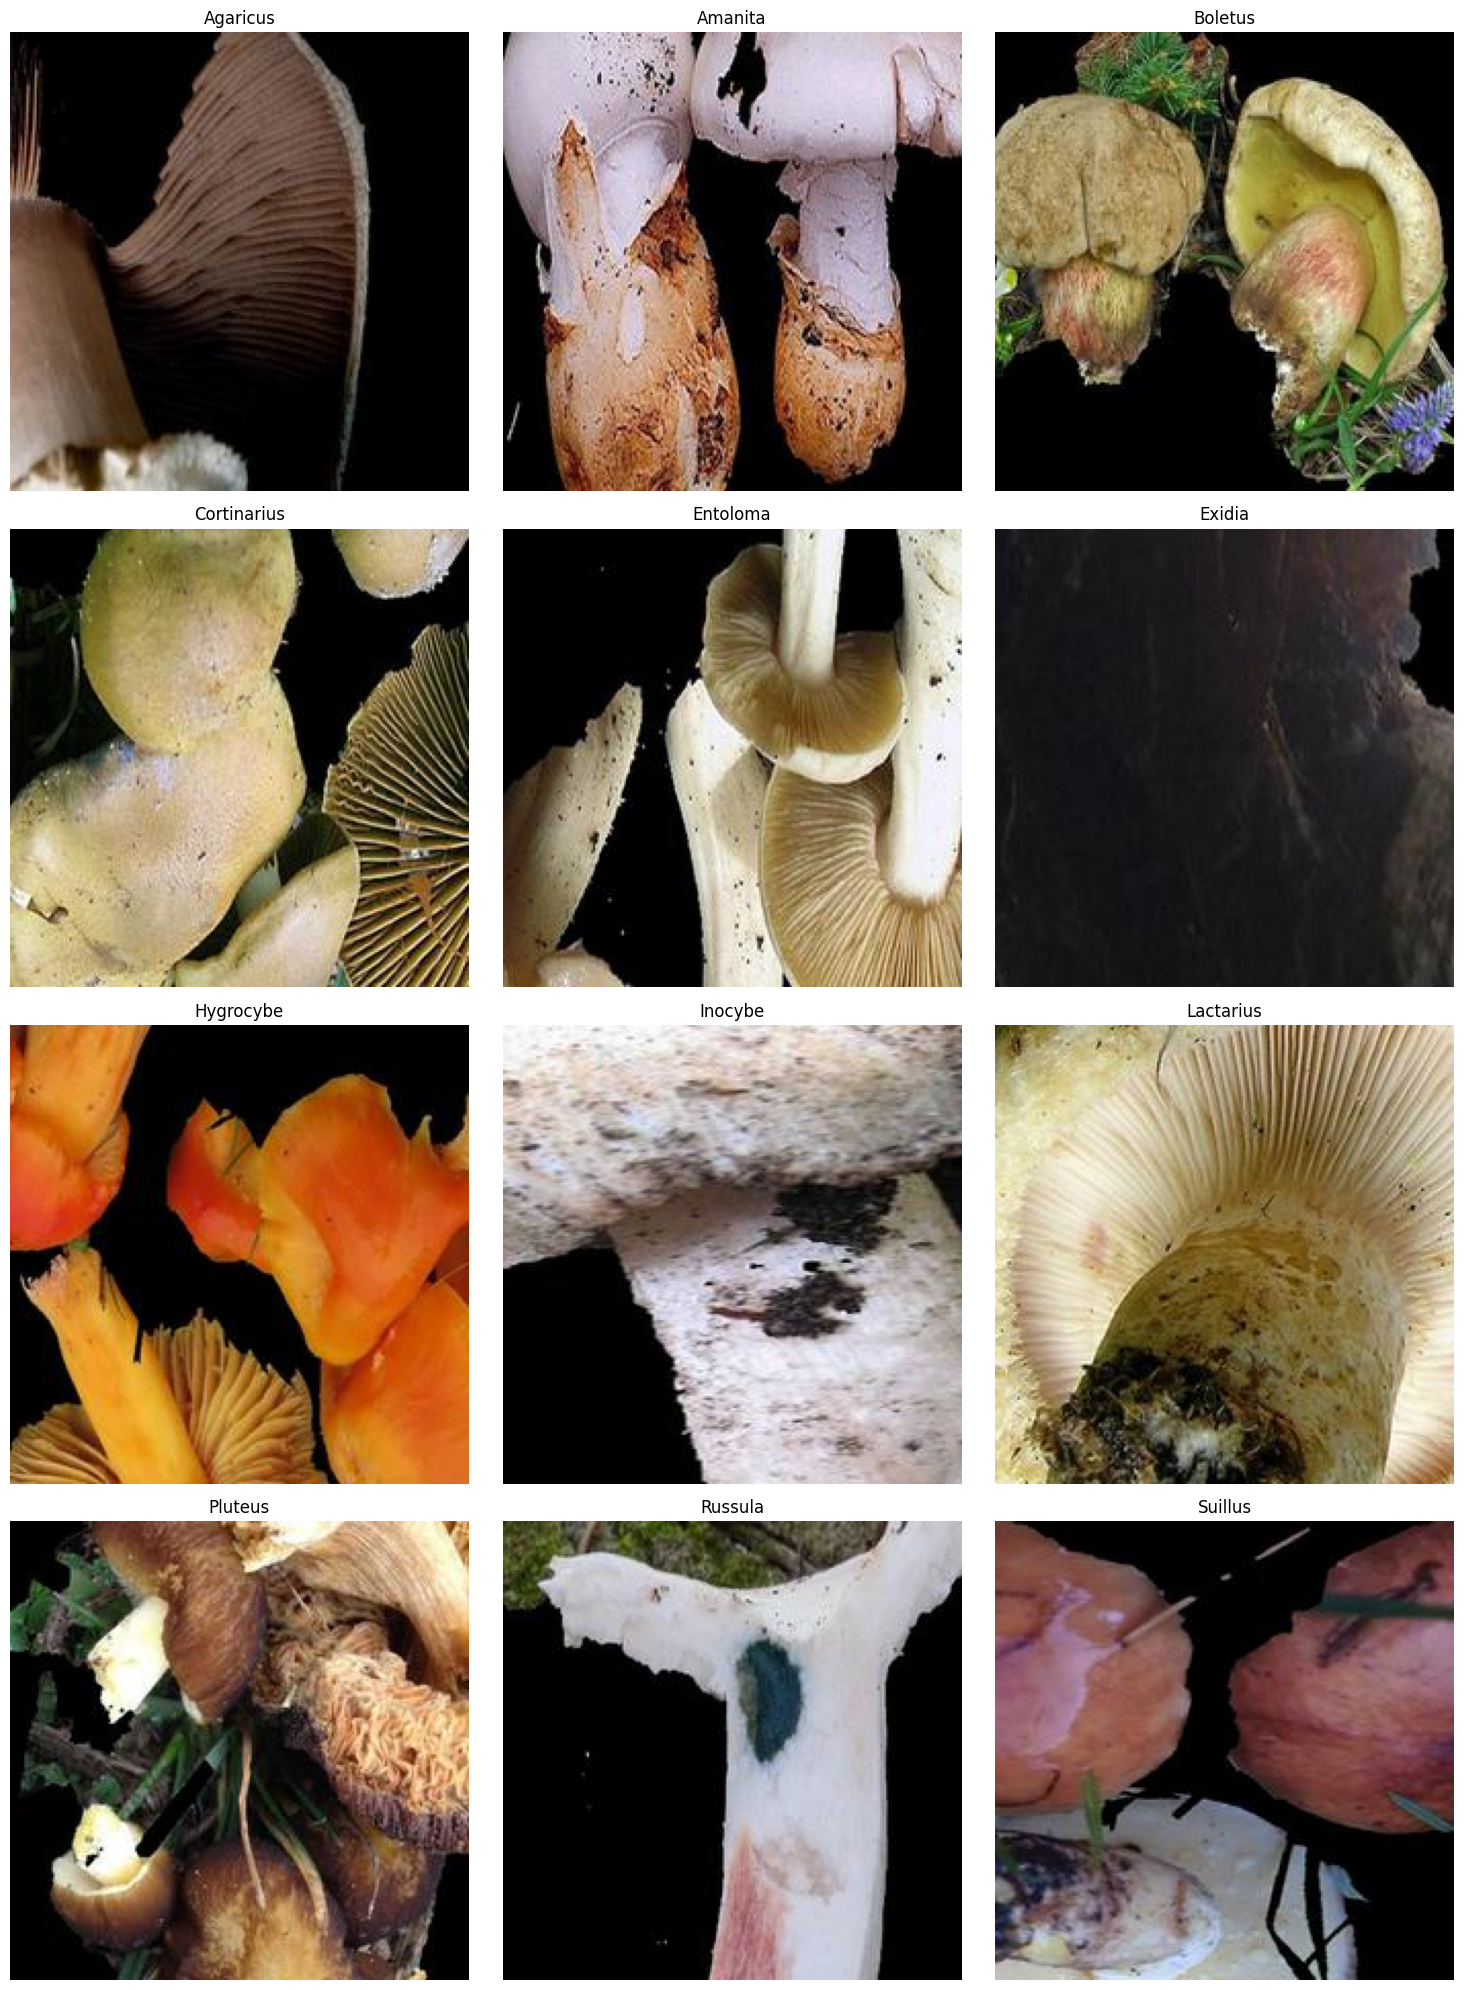

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import math

class_names = full_dataset.classes
print(f"Classes: {class_names}")

num_classes = len(class_names)
cols = 3
rows = math.ceil(num_classes / cols)
plt.figure(figsize=(15, 5 * rows))

for i, class_name in enumerate(class_names):
    class_folder = os.path.join(data_dir, class_name)

    if os.path.isdir(class_folder):
        files = os.listdir(class_folder)
        if len(files) > 0:
            img_path = os.path.join(class_folder, files[0])

            img = Image.open(img_path)

            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")

plt.tight_layout()
plt.show()

**MODEL**: MushroomResNet

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class MushroomResNet(nn.Module):
    def __init__(self, num_classes, freeze_layers=True):
        super(MushroomResNet, self).__init__()

        # Upload ResNet18
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        if freeze_layers:
            for param in self.resnet.parameters():
                param.requires_grad = True

        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.resnet(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(full_dataset.classes) # Assicurati che full_dataset sia definito

# Create the model
model = MushroomResNet(num_classes=num_classes, freeze_layers=True)
model = model.to(device)

print(f"Model MushroomResNet uploaded on {device} for {num_classes} classes.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 236MB/s]


Model MushroomResNet uploaded on cuda for 12 classes.


Model settings

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"The device used is: {device}")

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4) # Learning rate

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=3,
)

The device used is: cuda


Model train start

Start the train on cuda...
The best model would be saved on: /content/drive/MyDrive/Deep_learning_project/best_mushroom_model.pth
Epoch [1/30] | Train Loss: 1.5250 | Val Loss: 1.0125 | Val Acc: 65.08%
--> Improvement! Model saving... (Accuracy: 0.00% -> 65.08%)
Epoch [2/30] | Train Loss: 1.0962 | Val Loss: 0.7280 | Val Acc: 75.83%
--> Improvement! Model saving... (Accuracy: 65.08% -> 75.83%)
Epoch [3/30] | Train Loss: 0.9177 | Val Loss: 0.6489 | Val Acc: 78.92%
--> Improvement! Model saving... (Accuracy: 75.83% -> 78.92%)
Epoch [4/30] | Train Loss: 0.8225 | Val Loss: 0.5997 | Val Acc: 80.17%
--> Improvement! Model saving... (Accuracy: 78.92% -> 80.17%)
Epoch [5/30] | Train Loss: 0.7285 | Val Loss: 0.5555 | Val Acc: 83.17%
--> Improvement! Model saving... (Accuracy: 80.17% -> 83.17%)


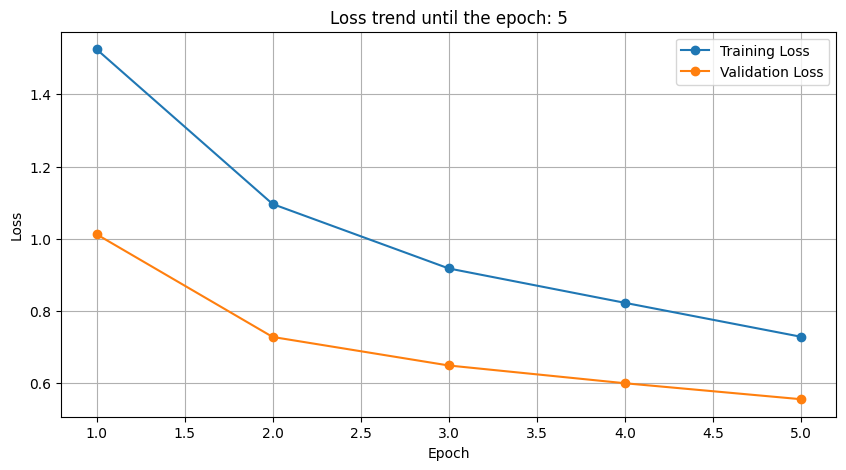

Epoch [6/30] | Train Loss: 0.6717 | Val Loss: 0.5227 | Val Acc: 82.92%
Epoch [7/30] | Train Loss: 0.6078 | Val Loss: 0.4670 | Val Acc: 84.92%
--> Improvement! Model saving... (Accuracy: 83.17% -> 84.92%)
Epoch [8/30] | Train Loss: 0.5682 | Val Loss: 0.5006 | Val Acc: 83.83%
Epoch [9/30] | Train Loss: 0.5387 | Val Loss: 0.4506 | Val Acc: 85.08%
--> Improvement! Model saving... (Accuracy: 84.92% -> 85.08%)
Epoch [10/30] | Train Loss: 0.5066 | Val Loss: 0.4482 | Val Acc: 85.50%
--> Improvement! Model saving... (Accuracy: 85.08% -> 85.50%)


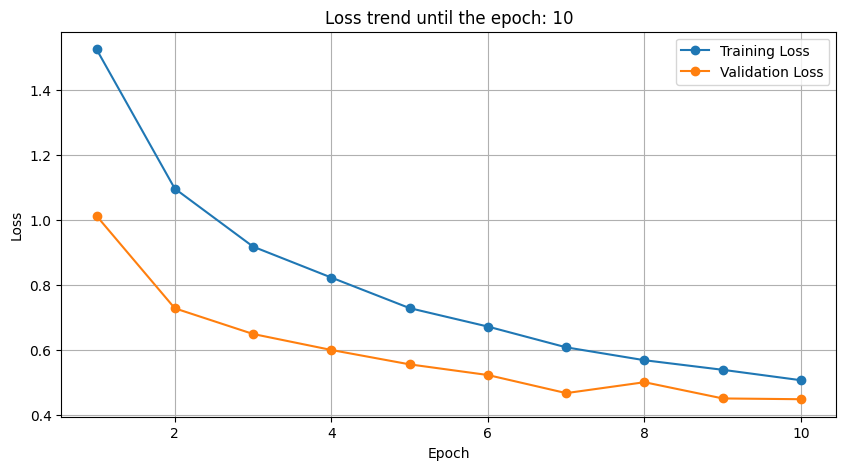

Epoch [11/30] | Train Loss: 0.4719 | Val Loss: 0.4257 | Val Acc: 87.92%
--> Improvement! Model saving... (Accuracy: 85.50% -> 87.92%)
Epoch [12/30] | Train Loss: 0.4518 | Val Loss: 0.4388 | Val Acc: 86.33%
Epoch [13/30] | Train Loss: 0.4605 | Val Loss: 0.4136 | Val Acc: 86.50%
Epoch [14/30] | Train Loss: 0.4376 | Val Loss: 0.3844 | Val Acc: 88.17%
--> Improvement! Model saving... (Accuracy: 87.92% -> 88.17%)
Epoch [15/30] | Train Loss: 0.4171 | Val Loss: 0.3673 | Val Acc: 87.83%


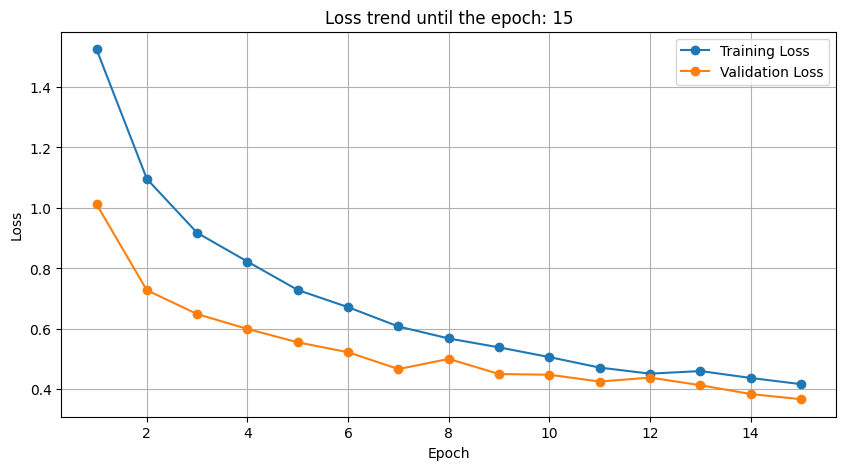

Epoch [16/30] | Train Loss: 0.3938 | Val Loss: 0.3610 | Val Acc: 89.58%
--> Improvement! Model saving... (Accuracy: 88.17% -> 89.58%)
Epoch [17/30] | Train Loss: 0.3940 | Val Loss: 0.3306 | Val Acc: 89.42%
Epoch [18/30] | Train Loss: 0.3808 | Val Loss: 0.3281 | Val Acc: 89.50%
Epoch [19/30] | Train Loss: 0.3635 | Val Loss: 0.3503 | Val Acc: 88.42%
Epoch [20/30] | Train Loss: 0.3521 | Val Loss: 0.3722 | Val Acc: 89.17%


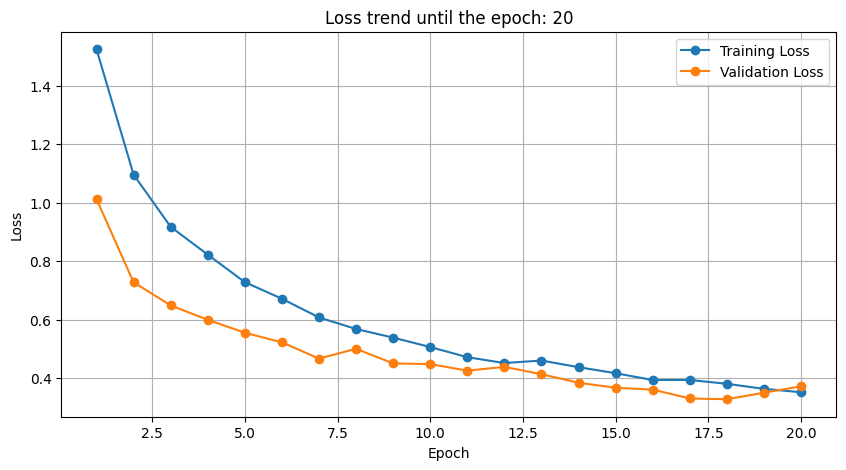

Epoch [21/30] | Train Loss: 0.3484 | Val Loss: 0.3992 | Val Acc: 88.92%
Epoch [22/30] | Train Loss: 0.3582 | Val Loss: 0.3699 | Val Acc: 88.83%
Epoch [23/30] | Train Loss: 0.2830 | Val Loss: 0.2557 | Val Acc: 91.33%
--> Improvement! Model saving... (Accuracy: 89.58% -> 91.33%)
Epoch [24/30] | Train Loss: 0.2567 | Val Loss: 0.2425 | Val Acc: 92.33%
--> Improvement! Model saving... (Accuracy: 91.33% -> 92.33%)
Epoch [25/30] | Train Loss: 0.2492 | Val Loss: 0.2425 | Val Acc: 91.92%


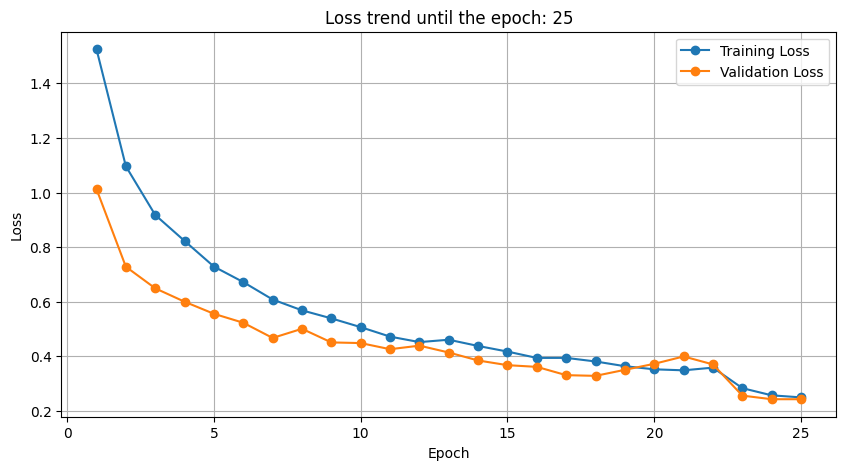

Epoch [26/30] | Train Loss: 0.2380 | Val Loss: 0.2450 | Val Acc: 91.83%
Epoch [27/30] | Train Loss: 0.2304 | Val Loss: 0.2325 | Val Acc: 92.67%
--> Improvement! Model saving... (Accuracy: 92.33% -> 92.67%)
Epoch [28/30] | Train Loss: 0.2243 | Val Loss: 0.2251 | Val Acc: 92.58%
Epoch [29/30] | Train Loss: 0.2169 | Val Loss: 0.2269 | Val Acc: 93.08%
--> Improvement! Model saving... (Accuracy: 92.67% -> 93.08%)
Epoch [30/30] | Train Loss: 0.2241 | Val Loss: 0.2278 | Val Acc: 92.50%


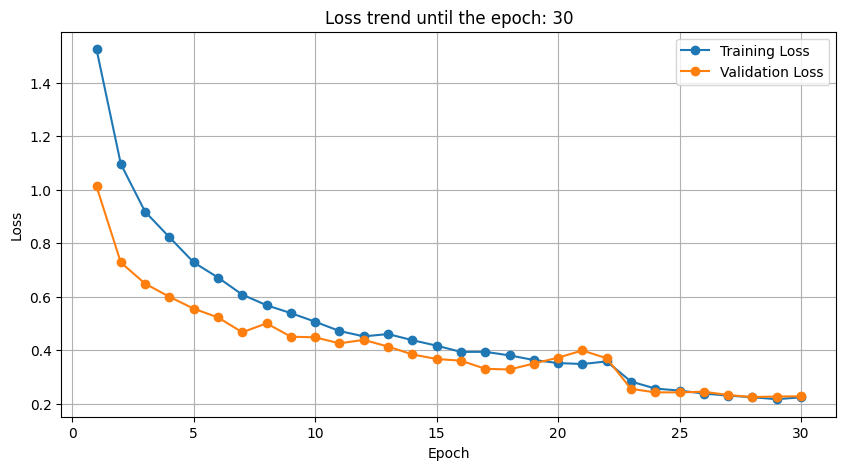

------------------------------
Trained completed! Best accuracy reached: 93.08%
Model saved in: /content/drive/MyDrive/Deep_learning_project/best_mushroom_model.pth


In [ ]:
import matplotlib.pyplot as plt
import torch
import os
import torch.optim as optim
from IPython.display import clear_output

save_path = '/content/drive/MyDrive/Deep_learning_project/best_mushroom_model.pth'

best_val_acc = 0.0
train_losses = []
val_losses = []

num_epochs = 30

print(f"Start the train on {device}...")
print(f"The best model would be saved on: {save_path}")


# TRAIN
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

  # VALIDATION
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100 * correct_val / total_val

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Best model saved
    if val_acc > best_val_acc:
        print(f"--> Improvement! Model saving... (Accuracy: {best_val_acc:.2f}% -> {val_acc:.2f}%)")
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)

    # PLOT
    if (epoch + 1) % 5 == 0:
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, epoch + 2), train_losses, label='Training Loss', marker='o')
        plt.plot(range(1, epoch + 2), val_losses, label='Validation Loss', marker='o')
        plt.title(f'Loss trend until the epoch: {epoch + 1}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

print("-" * 30)
print(f"Trained completed! Best accuracy reached: {best_val_acc:.2f}%")
print(f"Model saved in: {save_path}")

**CONFUSION MATRIX**

Start valutation in Test Set...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Agaricus       0.90      0.95      0.92       196
     Amanita       0.95      0.94      0.95       191
     Boletus       0.97      0.96      0.96       223
 Cortinarius       0.92      0.91      0.92       199
    Entoloma       0.90      0.90      0.90       183
      Exidia       0.99      0.99      0.99       202
   Hygrocybe       0.96      0.98      0.97       221
     Inocybe       0.93      0.89      0.91       216
   Lactarius       0.87      0.91      0.89       184
     Pluteus       0.94      0.99      0.96       198
     Russula       0.93      0.86      0.89       183
     Suillus       0.95      0.93      0.94       204

    accuracy                           0.93      2400
   macro avg       0.93      0.93      0.93      2400
weighted avg       0.94      0.93      0.93      2400



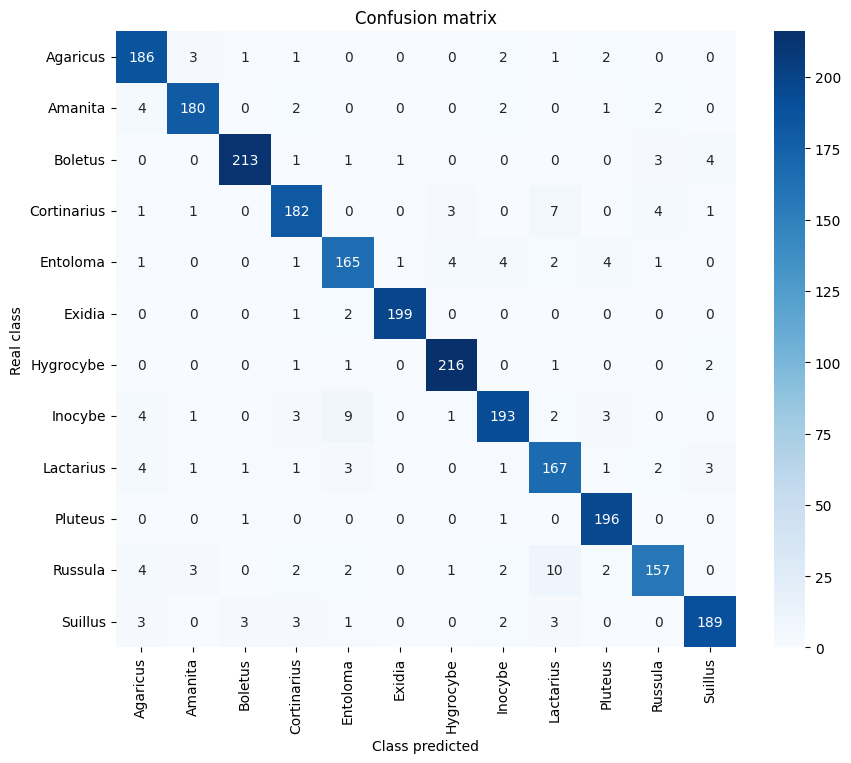

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

model.eval()

y_true = []
y_pred_idx = []
y_probs = []

print("Start valutation in Test Set...")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred_idx.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred_idx = np.array(y_pred_idx)
y_probs = np.array(y_probs)

class_names = full_dataset.classes

# CLASSIFICATION REPORT
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred_idx, target_names=class_names))

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred_idx)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Class predicted')
plt.ylabel('Real class')
plt.title('Confusion matrix')
plt.show()

**ROC CURVE and AUC**

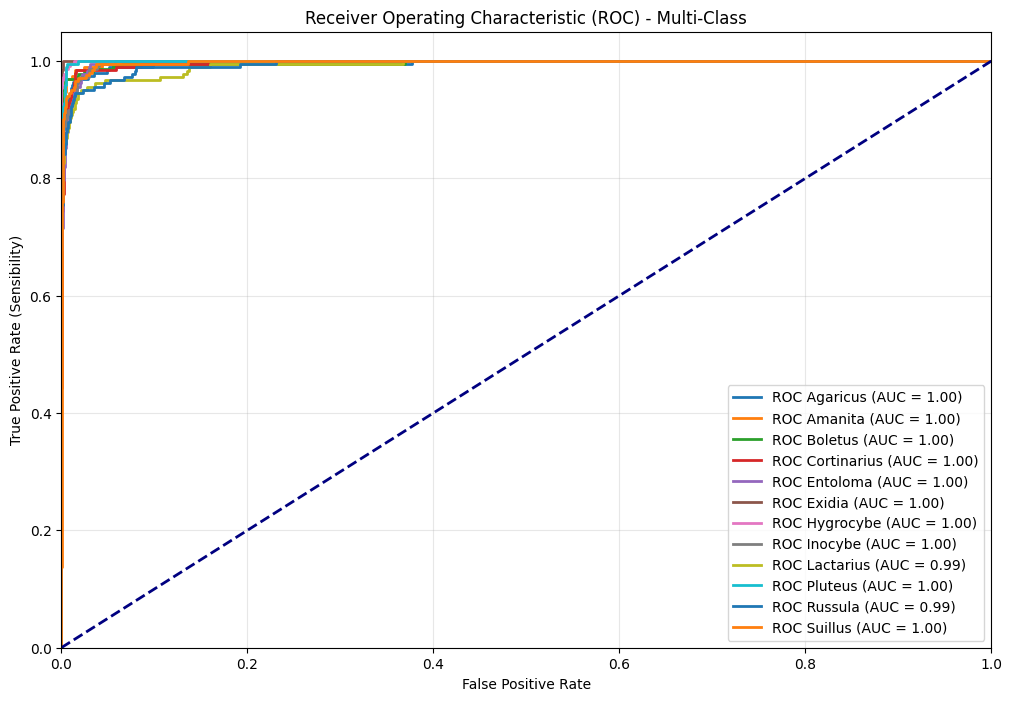

In [ ]:
n_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

plt.figure(figsize=(12, 8))

for i in range(n_classes):
    # Compute FPR e TPR
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot the curve
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensibility)')
plt.title('Receiver Operating Characteristic (ROC) - Multi-Class')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()